# Анализ отзывов об обслуживании юридических лиц (banki.ru)

## Постановка задачи

**Цель курсовой работы** — выявить, какие текстовые признаки отзывов клиентов-юридических лиц на сайте banki.ru определяют их удовлетворённость обслуживанием, и построить интерпретируемую baseline-модель.

### Целевая переменная

`y` — бинарная удовлетворённость:
- `1` — отзыв с оценкой 4–5 (удовлетворён),
- `0` — отзыв с оценкой 1–2 (не удовлетворён).

Отзывы с оценкой 3 исключаются как нейтральные, чтобы получить более чистый сигнал.

### Независимые переменные (факторы)

Выделяются из текста отзыва на основе:
- частотного анализа слов и биграмм;
- TF-IDF-векторизации;
- интерпретации коэффициентов логистической регрессии.

### Гипотезы (проверяются по найденным значимым словам и темам)

1. **Оперативность коммуникаций** влияет на удовлетворённость (быстро/долго/задержка/оперативно...).
2. **Качество поддержки** влияет на удовлетворённость (менеджер/оператор/специалист/помог...).
3. **Персонализация взаимодействия** влияет на удовлетворённость (индивидуальный/персональный/подход/внимание...).

### Этапы

1. Сбор данных (парсер `scraper.py`, см. отдельный модуль).
2. Очистка и нормализация текста, удаление стоп-слов.
3. Лемматизация (pymorphy3).
4. Векторизация TF-IDF.
5. Частотный анализ и тематические маркеры.
6. Обучение логистической регрессии.
7. Интерпретация коэффициентов и проверка гипотез.


## 1. Загрузка собранных данных

Источник — отзывы об обслуживании юридических лиц с banki.ru
(`https://www.banki.ru/services/responses/list/?type=business`).
Парсер сохраняет батчами в `data/raw/*.parquet`.


In [1]:
import glob, os, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("data/raw")
files = sorted(DATA_DIR.glob("reviews_*.parquet"))
print(f"Найдено {len(files)} parquet-файлов")

df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
df = df.drop_duplicates(subset=["review_id"]).reset_index(drop=True)
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(f"Всего уникальных отзывов: {len(df):,}")
print(f"Диапазон дат: {df['date'].min()} ... {df['date'].max()}")
df.head(3)

Найдено 8 parquet-файлов


Всего уникальных отзывов: 8,524
Диапазон дат: 2026-05-21 09:31:42 ... 2026-05-24 13:39:54


,review_id,bank,bank_code,rating,date,title,text,url,is_business
0,13125359,Альфа-Банк,alfabank,5.0,2026-05-24 13:39:54,Получил детскую дебетовую карту,"Оформил заявку на детскую дебетовую карту, представитель банка позвонил в назначенный день и предупредил о том, в какое время будет, по прибытию позвонил еще раз, уведомив меня что он на месте! вс...",https://www.banki.ru/services/responses/bank/response/13125359/,True
1,13125358,Альфа-Банк,alfabank,5.0,2026-05-24 13:39:21,Комиссии,17-18 января списали деньги за альфа смарт и меня не проинформировали что за него будут списывать деньги. Создала обращение о том что у меня списали и не проинформировали и в тот же день вернули д...,https://www.banki.ru/services/responses/bank/response/13125358/,True
2,13125357,Альфа-Банк,alfabank,5.0,2026-05-24 13:38:38,Отличный сервис и грамотная консультация,"Мне нужно было срочно получить 100.000 ₽ на месяц без процентов, так как не хватило бюджета на ремонт. 12 мая зашла в приложение Альфа-банка для поиска кредитных предложений. Так как не разбираюсь...",https://www.banki.ru/services/responses/bank/response/13125357/,True


Распределение оценок:
rating
1.0     613
2.0      74
3.0      51
4.0     193
5.0    7543
Name: count, dtype: int64

Топ-10 банков по количеству отзывов:
bank
Альфа-Банк          4051
Вайлдберриз Банк     946
Совкомбанк           884
Ozon Банк            404
Т-Банк               359
КАМКОМБАНК           347
Русский Стандарт     177
ЮMoney               173
ВТБ                  166
Россельхозбанк       139
Name: count, dtype: int64

Статистика длины текста (символов):
count    8524.0
mean      566.5
std       446.0
min        71.0
25%       324.0
50%       389.0
75%       609.0
max      3602.0
Name: text, dtype: float64


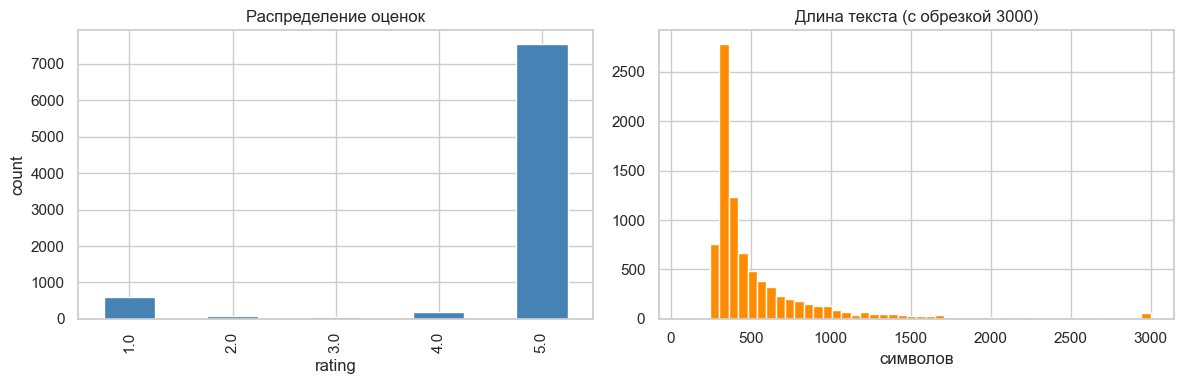

In [2]:
# Сводная статистика
print("Распределение оценок:")
print(df["rating"].value_counts().sort_index())

print("\nТоп-10 банков по количеству отзывов:")
print(df["bank"].value_counts().head(10))

print("\nСтатистика длины текста (символов):")
print(df["text"].str.len().describe().round(1))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["rating"].value_counts().sort_index().plot(kind="bar", ax=ax[0], color="steelblue")
ax[0].set_title("Распределение оценок"); ax[0].set_xlabel("rating"); ax[0].set_ylabel("count")
df["text"].str.len().clip(upper=3000).hist(bins=50, ax=ax[1], color="darkorange")
ax[1].set_title("Длина текста (с обрезкой 3000)"); ax[1].set_xlabel("символов")
plt.tight_layout(); plt.show()

## 2. Формирование целевой переменной

Бинаризуем: 4–5 → `1` (удовлетворён), 1–2 → `0` (не удовлетворён), 3 → исключаем.


После исключения рейтинга 3: 8,473 отзывов
Баланс классов:
y
удовлетворён       0.913
не удовлетворён    0.087
Name: proportion, dtype: float64


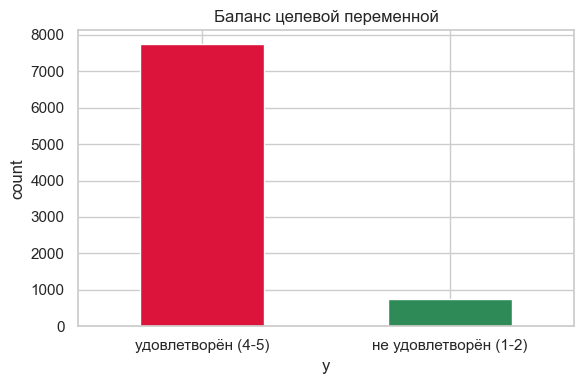

In [3]:
df_bin = df[df["rating"] != 3].copy()
df_bin["y"] = (df_bin["rating"] >= 4).astype(int)

print(f"После исключения рейтинга 3: {len(df_bin):,} отзывов")
print("Баланс классов:")
print(df_bin["y"].value_counts(normalize=True).rename({0: "не удовлетворён", 1: "удовлетворён"}).round(3))

df_bin["y"].value_counts().rename({0: "не удовлетворён (1-2)", 1: "удовлетворён (4-5)"}).plot(
    kind="bar", color=["crimson", "seagreen"], figsize=(6, 4)
)
plt.title("Баланс целевой переменной"); plt.ylabel("count"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 3. Этап 1 — очистка и нормализация текста

- приведение к нижнему регистру;
- удаление URL, email, цифр, пунктуации;
- оставляем только кириллицу и пробелы;
- схлопывание пробелов;
- отбрасываем отзывы короче 20 символов после очистки.


In [4]:
URL_RE   = re.compile(r"https?://\S+|www\.\S+")
EMAIL_RE = re.compile(r"\S+@\S+\.\S+")
NON_CYR  = re.compile(r"[^а-яёА-ЯЁ\s]")
SPACE_RE = re.compile(r"\s+")

def clean_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = URL_RE.sub(" ", s)
    s = EMAIL_RE.sub(" ", s)
    s = s.replace("ё", "е")
    s = NON_CYR.sub(" ", s)
    s = SPACE_RE.sub(" ", s).strip()
    return s

# Объединяем заголовок и текст
df_bin["text_full"] = (df_bin["title"].fillna("") + ". " + df_bin["text"].fillna("")).str.strip()
df_bin["text_clean"] = df_bin["text_full"].apply(clean_text)
df_bin = df_bin[df_bin["text_clean"].str.len() >= 20].reset_index(drop=True)

print(f"После очистки осталось: {len(df_bin):,} отзывов")
print("Пример:")
print("raw  :", df_bin["text_full"].iloc[0][:200])
print("clean:", df_bin["text_clean"].iloc[0][:200])

После очистки осталось: 8,472 отзывов
Пример:
raw  : Получил детскую дебетовую карту. Оформил заявку на детскую дебетовую карту, представитель банка позвонил в назначенный день и предупредил о том, в какое время будет, по прибытию позвонил еще раз, увед
clean: получил детскую дебетовую карту оформил заявку на детскую дебетовую карту представитель банка позвонил в назначенный день и предупредил о том в какое время будет по прибытию позвонил еще раз уведомив 


## 4. Этап 1 — лемматизация и удаление стоп-слов

Лемматизация русского текста — `pymorphy3`. Стоп-слова — `nltk.corpus.stopwords.words("russian")` + кастомный список банковских/общих шумов (`банк`, `отзыв`, `здравствуйте`, ...).

Результат кэшируется в `data/processed.parquet`, чтобы при повторных запусках не пересчитывать.


In [5]:
import pymorphy3
from tqdm.auto import tqdm

tqdm.pandas()

import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

RUS_STOPS = set(stopwords.words("russian"))

# Кастомные стоп-слова: общеупотребительные банковские шумы, не несущие сигнала
CUSTOM_STOPS = {
    "банк", "банка", "банке", "банком", "банкам", "банки", "банков", "банкомат",
    "отзыв", "отзыва", "отзывы", "отзыву",
    "здравствуйте", "добрый", "день", "вечер", "утро",
    "спасибо", "благодарю",
    "это", "этот", "эта", "эти",
    "который", "которая", "которое", "которые",
    "очень", "также", "тоже", "еще", "уже",
    "мочь", "мой", "свой", "наш", "весь", "такой", "какой",
    "быть", "стать", "сказать", "говорить",
}
STOPS = RUS_STOPS | CUSTOM_STOPS
print(f"Стоп-слов: {len(STOPS)} (русских {len(RUS_STOPS)} + кастомных {len(CUSTOM_STOPS)})")

morph = pymorphy3.MorphAnalyzer()
_cache = {}
def lemma(token: str) -> str:
    r = _cache.get(token)
    if r is None:
        r = morph.parse(token)[0].normal_form
        _cache[token] = r
    return r

def lemmatize(text: str) -> str:
    out = []
    for tok in text.split():
        if len(tok) < 3:
            continue
        lm = lemma(tok)
        if lm in STOPS or len(lm) < 3:
            continue
        out.append(lm)
    return " ".join(out)

PROC_COLS = ["review_id", "bank", "rating", "date", "title", "text", "text_clean", "text_lemm", "y"]
CACHE_FILE = Path("data/processed.parquet")

if CACHE_FILE.exists():
    cached = pd.read_parquet(CACHE_FILE)
    cached = cached[cached["review_id"].isin(df_bin["review_id"])]
    todo = df_bin[~df_bin["review_id"].isin(cached["review_id"])].copy()
    print(f"Найден кеш: {len(cached):,}, нужно лемматизировать ещё: {len(todo):,}")
    if len(todo):
        todo["text_lemm"] = todo["text_clean"].progress_apply(lemmatize)
        new_rows = todo[[c for c in PROC_COLS if c in todo.columns]]
        cached = pd.concat([cached, new_rows], ignore_index=True)
    df_proc = cached
else:
    df_bin["text_lemm"] = df_bin["text_clean"].progress_apply(lemmatize)
    df_proc = df_bin[PROC_COLS].copy()

df_proc.to_parquet(CACHE_FILE, index=False)
df_proc = df_proc[df_proc["text_lemm"].str.len() >= 5].reset_index(drop=True)
print(f"После лемматизации: {len(df_proc):,} отзывов")
print("Пример лемматизированного текста:")
print(df_proc["text_lemm"].iloc[0][:300])

Стоп-слов: 185 (русских 151 + кастомных 43)


  0%|          | 0/8472 [00:00<?, ?it/s]

После лемматизации: 8,472 отзывов
Пример лемматизированного текста:
получить детский дебетовый карта оформить заявка детский дебетовый карта представитель позвонить назначить предупредить время прибытие позвонить ещё уведомить место всё быстро оформить проверить документ дополнительно помочь установить приложение альфа ранее пользоваться веб версия всё пройти успешн


## 5. Этап 2 — преобразование текста в TF-IDF

Параметры подобраны для интерпретируемой модели:
- `min_df=10` — отбрасываем слишком редкие термины (шум);
- `max_df=0.6` — отбрасываем слишком частые (мало информации);
- `ngram_range=(1,2)` — слова и биграммы (тематические маркеры часто двусловные);
- `max_features=20000` — ограничение для скорости.


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Адаптируем min_df под размер выборки
n = len(df_proc)
min_df = max(5, int(n * 0.0005))   # минимум 0.05% документов
max_features = min(20000, max(2000, n // 5))

vec = TfidfVectorizer(
    min_df=min_df,
    max_df=0.6,
    ngram_range=(1, 2),
    max_features=max_features,
    sublinear_tf=True,
)
X = vec.fit_transform(df_proc["text_lemm"])
vocab = vec.get_feature_names_out()

print(f"min_df={min_df}, max_features={max_features}")
print(f"TF-IDF матрица: shape={X.shape}, nnz={X.nnz:,}, density={X.nnz / (X.shape[0]*X.shape[1]):.5%}")
print(f"Размер словаря: {len(vocab):,}")
print("Случайные термины:", list(np.random.RandomState(0).choice(vocab, 15, replace=False)))

min_df=5, max_features=2000
TF-IDF матрица: shape=(8472, 2000), nnz=368,397, density=2.17420%
Размер словаря: 2,000
Случайные термины: ['доход', 'подождать', 'пластиковый карта', 'минимальный', 'срочно', 'поделиться опыт', 'рассказать условие', 'понятный интерфейс', 'узнать', 'алексей', 'пользоваться дебетовый', 'реакция', 'всё таки', 'возникнуть проблема', 'мелкий']


## 6. Этап 3 — частотный анализ

Смотрим:
- топ слов по document frequency (DF) — что вообще обсуждается в отзывах;
- топ биграмм — устойчивые словосочетания;
- разница в употреблении между классами `y=0` и `y=1`.


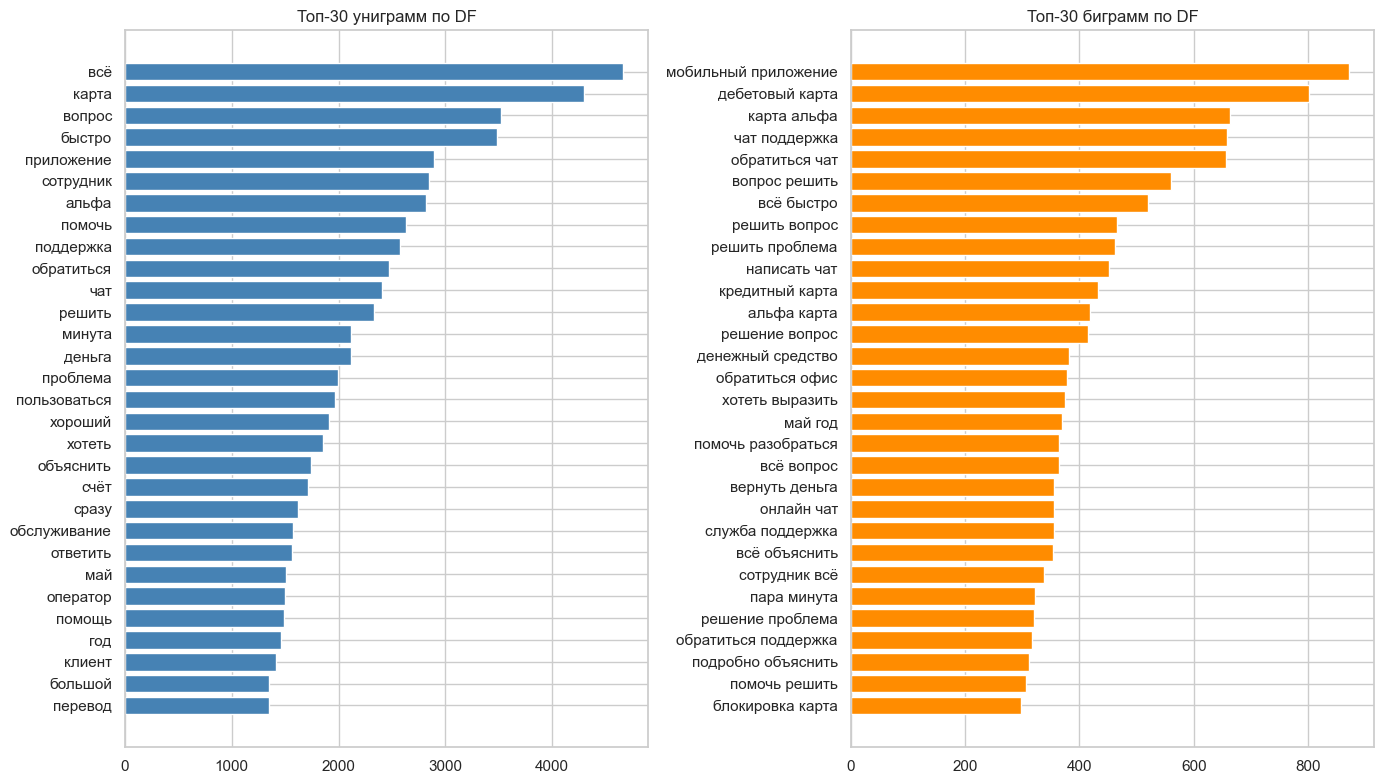

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

# DF (в скольких документах встречается)
df_counts = (X > 0).astype(int).sum(axis=0).A1
df_terms = pd.DataFrame({"term": vocab, "df": df_counts}).sort_values("df", ascending=False)

# Разделяем на униграммы и биграммы
df_uni = df_terms[~df_terms["term"].str.contains(" ")].head(30)
df_bi  = df_terms[ df_terms["term"].str.contains(" ")].head(30)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].barh(df_uni["term"][::-1], df_uni["df"][::-1], color="steelblue")
axes[0].set_title("Топ-30 униграмм по DF")
axes[1].barh(df_bi["term"][::-1], df_bi["df"][::-1], color="darkorange")
axes[1].set_title("Топ-30 биграмм по DF")
plt.tight_layout(); plt.show()

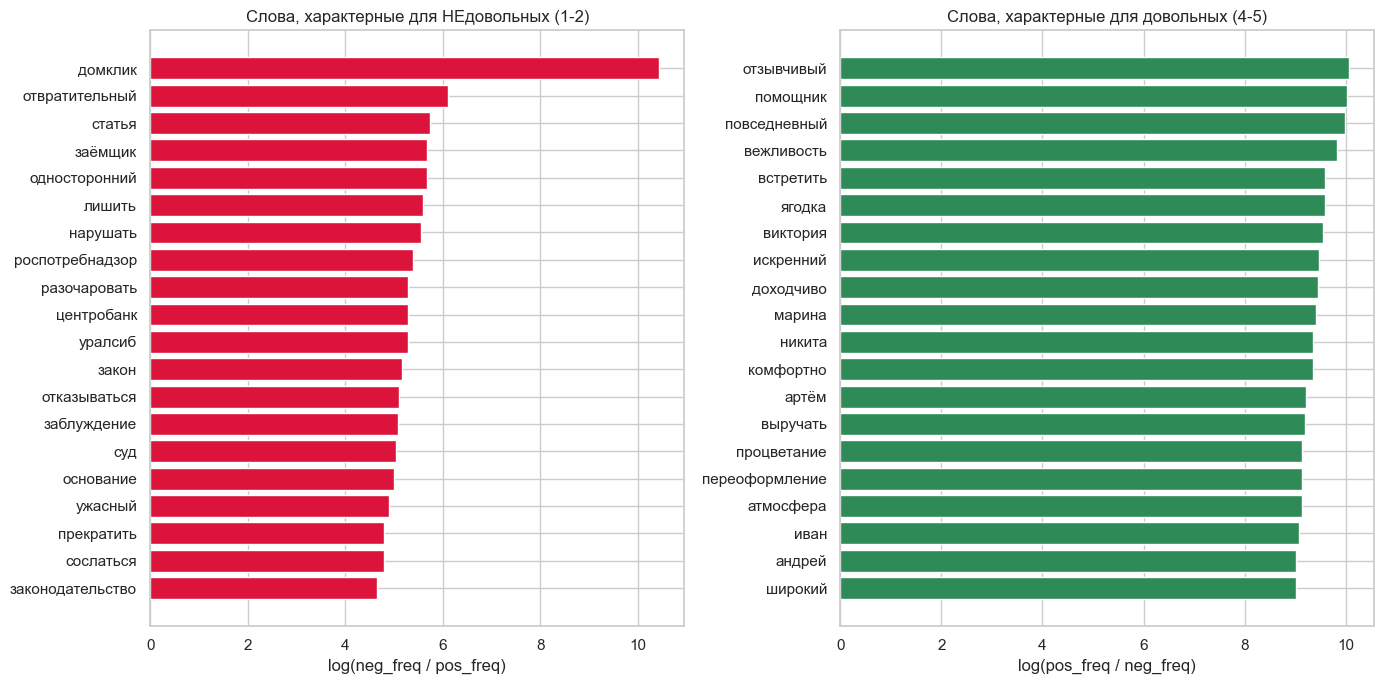

In [8]:
# Сравнение топа в позитивных vs негативных отзывах через CountVectorizer на тех же лемма-токенах
cv = CountVectorizer(min_df=min_df, max_df=0.6, ngram_range=(1, 1))
Xc = cv.fit_transform(df_proc["text_lemm"])
vocab_c = cv.get_feature_names_out()

y = df_proc["y"].values
pos_counts = Xc[y == 1].sum(axis=0).A1
neg_counts = Xc[y == 0].sum(axis=0).A1

# Нормируем на размер класса, чтобы можно было сравнивать частоты
pos_freq = pos_counts / max(1, (y == 1).sum())
neg_freq = neg_counts / max(1, (y == 0).sum())

# Log-ratio: насколько чаще встречается в негативных vs позитивных
eps = 1e-6
log_ratio_neg = np.log((neg_freq + eps) / (pos_freq + eps))

diff = pd.DataFrame({
    "term": vocab_c, "pos_freq": pos_freq, "neg_freq": neg_freq,
    "log_ratio_neg": log_ratio_neg,
    "total": pos_counts + neg_counts
})
# Только достаточно частые
diff = diff[diff["total"] >= max(20, min_df * 2)]

top_neg = diff.sort_values("log_ratio_neg", ascending=False).head(20)
top_pos = diff.sort_values("log_ratio_neg", ascending=True).head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].barh(top_neg["term"][::-1], top_neg["log_ratio_neg"][::-1], color="crimson")
axes[0].set_title("Слова, характерные для НЕдовольных (1-2)")
axes[0].set_xlabel("log(neg_freq / pos_freq)")
axes[1].barh(top_pos["term"][::-1], -top_pos["log_ratio_neg"][::-1], color="seagreen")
axes[1].set_title("Слова, характерные для довольных (4-5)")
axes[1].set_xlabel("log(pos_freq / neg_freq)")
plt.tight_layout(); plt.show()

## 7. Группировка по гипотезам (тематические маркеры)

Заранее задаём словари-маркеры для трёх гипотез из задания и смотрим, как доля «темовых» токенов связана с удовлетворённостью клиента. Это даёт *интерпретационное* подтверждение/опровержение ещё до модели.


Средняя доля темовых токенов в тексте по классам:
y                     не удовлетворён  удовлетворён
theme_оперативность            0.0102        0.0372
theme_поддержка                0.0296        0.0663
theme_персонализация           0.0097        0.0145


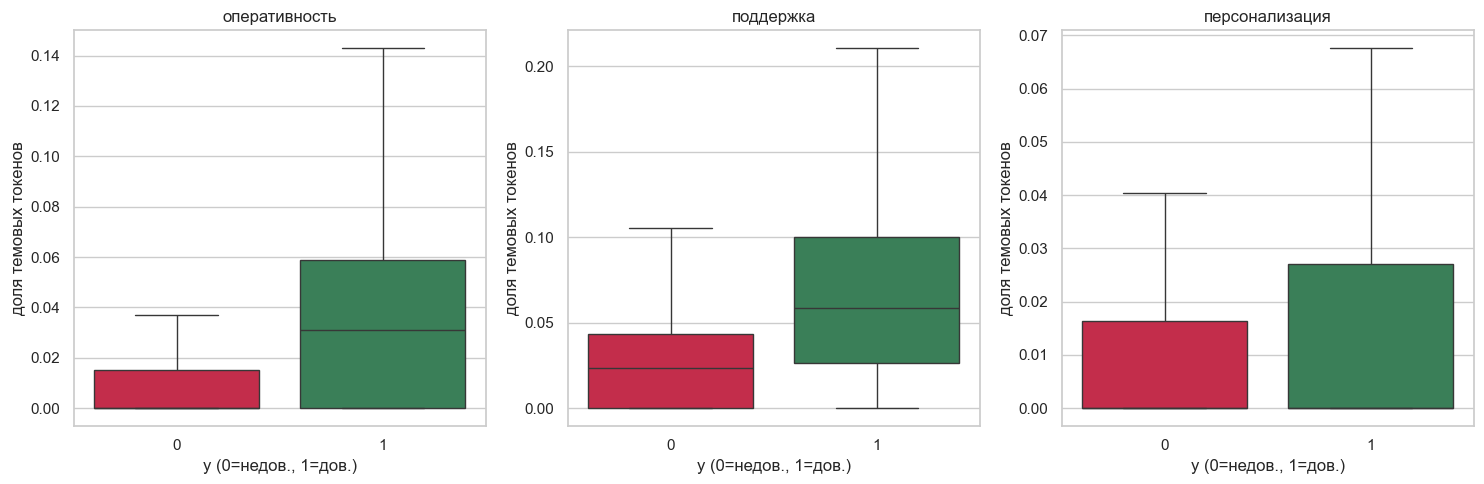

In [9]:
themes = {
    "оперативность": {
        "быстро", "быстрый", "оперативно", "оперативный", "оперативность",
        "долго", "долгий", "медленно", "медленный", "задержка", "ждать",
        "моментально", "мгновенно", "час", "минута", "день", "срок",
    },
    "поддержка": {
        "менеджер", "оператор", "специалист", "сотрудник", "поддержка",
        "консультант", "помочь", "помощь", "проконсультировать", "объяснить",
        "ответить", "перезвонить", "горячий", "линия", "чат",
    },
    "персонализация": {
        "индивидуальный", "персональный", "подход", "внимание", "внимательный",
        "забота", "заботливый", "клиент", "клиентоориентированный",
        "удобный", "комфортный", "вежливый", "вежливость",
    },
}

def theme_share(text: str, words: set) -> float:
    toks = text.split()
    if not toks:
        return 0.0
    hits = sum(1 for t in toks if t in words)
    return hits / len(toks)

for name, words in themes.items():
    df_proc[f"theme_{name}"] = df_proc["text_lemm"].apply(lambda t, w=words: theme_share(t, w))

summary = df_proc.groupby("y")[[f"theme_{k}" for k in themes]].mean().round(4)
summary.index = summary.index.map({0: "не удовлетворён", 1: "удовлетворён"})
print("Средняя доля темовых токенов в тексте по классам:")
print(summary.T)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, name in zip(axes, themes):
    sns.boxplot(
        data=df_proc, x="y", y=f"theme_{name}", ax=ax, showfliers=False,
        hue="y", palette={0: "crimson", 1: "seagreen"}, legend=False,
    )
    ax.set_title(name)
    ax.set_xlabel("y (0=недов., 1=дов.)")
    ax.set_ylabel("доля темовых токенов")
plt.tight_layout(); plt.show()

## 8. Этап 3 — baseline-модель (логистическая регрессия)

Используем интерпретируемую модель — `LogisticRegression` на TF-IDF.
`class_weight="balanced"` компенсирует возможный перекос классов.
Стратифицированный train/test 80/20.


train: (6777, 2000), test: (1695, 2000)
train pos share: 0.913, test pos share: 0.913

=== LogReg ===
                   precision    recall  f1-score   support

недовольный (1-2)      0.740     0.912     0.817       147
  довольный (4-5)      0.991     0.970     0.980      1548

         accuracy                          0.965      1695
        macro avg      0.866     0.941     0.899      1695
     weighted avg      0.970     0.965     0.966      1695

ROC-AUC: 0.9669
Baseline (most frequent) accuracy: 0.9133


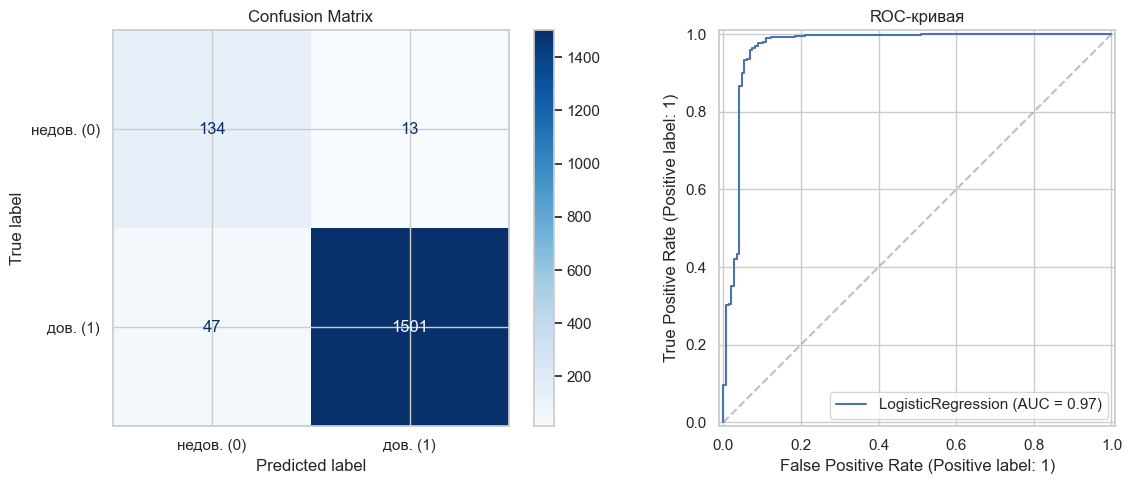

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
)
from sklearn.dummy import DummyClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, df_proc["y"].values, test_size=0.2, stratify=df_proc["y"].values, random_state=42
)
print(f"train: {X_train.shape}, test: {X_test.shape}")
print(f"train pos share: {y_train.mean():.3f}, test pos share: {y_test.mean():.3f}")

clf = LogisticRegression(
    max_iter=2000, C=1.0, class_weight="balanced",
    solver="liblinear", random_state=42,
)
clf.fit(X_train, y_train)

proba_test = clf.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

print("\n=== LogReg ===")
print(classification_report(y_test, pred_test, digits=3,
                            target_names=["недовольный (1-2)", "довольный (4-5)"]))
print(f"ROC-AUC: {roc_auc_score(y_test, proba_test):.4f}")

# Baseline сравнение: majority class
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print(f"Baseline (most frequent) accuracy: {(dummy.predict(X_test) == y_test).mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_test, ax=axes[0],
    display_labels=["недов. (0)", "дов. (1)"], cmap="Blues",
)
axes[0].set_title("Confusion Matrix")
RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=axes[1])
axes[1].set_title("ROC-кривая")
axes[1].plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)
plt.tight_layout(); plt.show()

## 9. Интерпретация коэффициентов

Веса логистической регрессии напрямую интерпретируемы: положительный коэффициент → термин повышает вероятность класса `1` (удовлетворён), отрицательный → понижает.

Сопоставляем топ-термины с заявленными гипотезами:
оперативность, поддержка, персонализация.


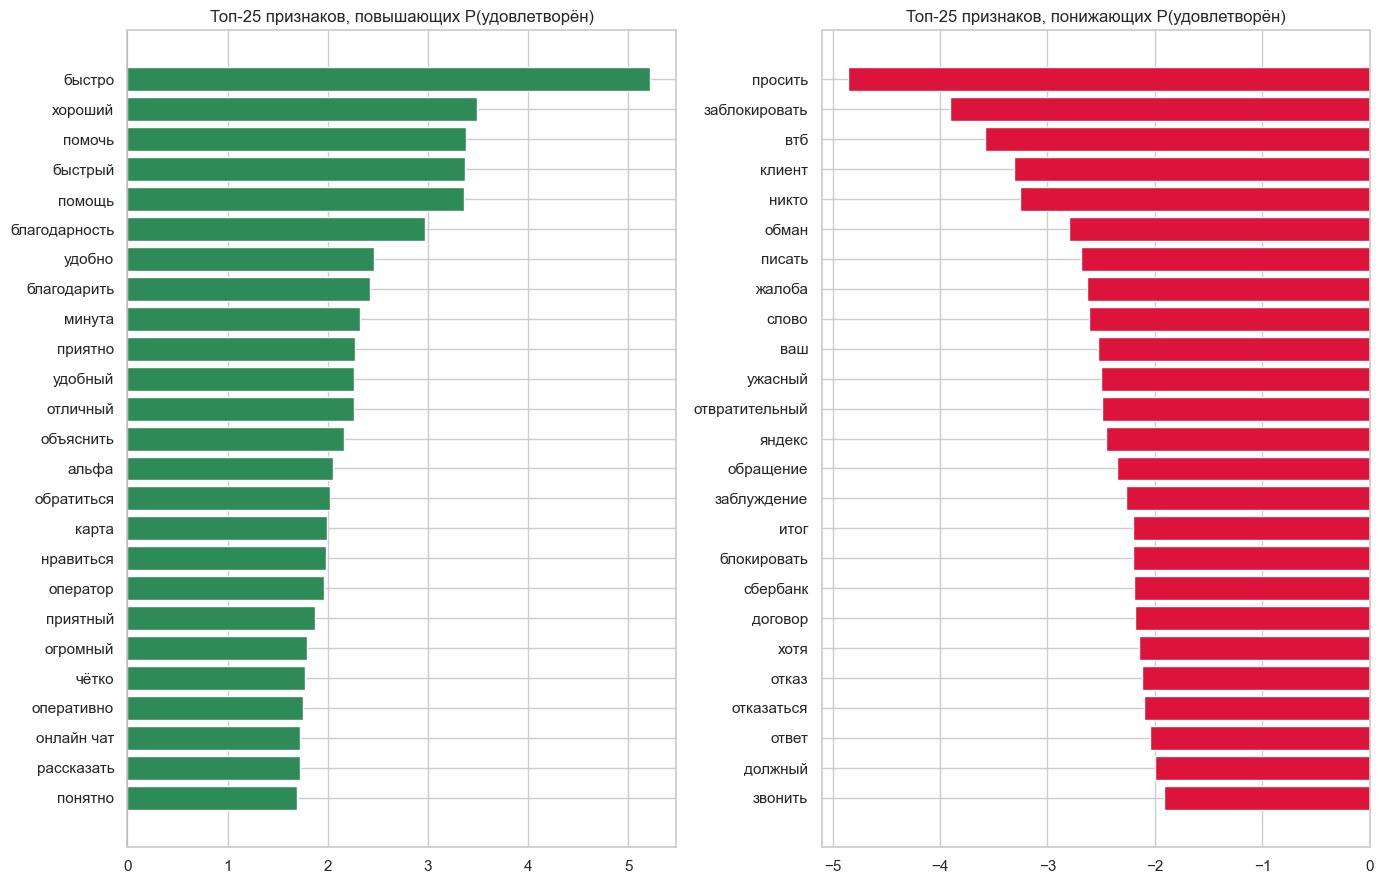

In [11]:
coefs = pd.DataFrame({"term": vocab, "coef": clf.coef_.ravel()})
coefs["abs"] = coefs["coef"].abs()

top_pos_terms = coefs.sort_values("coef", ascending=False).head(25)
top_neg_terms = coefs.sort_values("coef", ascending=True).head(25)

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
axes[0].barh(top_pos_terms["term"][::-1], top_pos_terms["coef"][::-1], color="seagreen")
axes[0].set_title("Топ-25 признаков, повышающих P(удовлетворён)")
axes[0].axvline(0, color="black", linewidth=0.5)
axes[1].barh(top_neg_terms["term"][::-1], top_neg_terms["coef"][::-1], color="crimson")
axes[1].set_title("Топ-25 признаков, понижающих P(удовлетворён)")
axes[1].axvline(0, color="black", linewidth=0.5)
plt.tight_layout(); plt.show()

In [12]:
# Привязка топ-коэффициентов к гипотезам
def label_term(term: str) -> str:
    for theme, words in themes.items():
        if any(w in term for w in words):
            return theme
    return "–"

annot_pos = top_pos_terms.copy()
annot_pos["гипотеза"] = annot_pos["term"].apply(label_term)
annot_neg = top_neg_terms.copy()
annot_neg["гипотеза"] = annot_neg["term"].apply(label_term)

print("=== Топ позитивных признаков с привязкой к гипотезам ===")
print(annot_pos[["term", "coef", "гипотеза"]].to_string(index=False))
print("\n=== Топ негативных признаков с привязкой к гипотезам ===")
print(annot_neg[["term", "coef", "гипотеза"]].to_string(index=False))

all_top = pd.concat([annot_pos, annot_neg])
print("\n=== Сколько топ-признаков покрывается каждой гипотезой ===")
print(all_top["гипотеза"].value_counts())

=== Топ позитивных признаков с привязкой к гипотезам ===
         term     coef       гипотеза
       быстро 5.211461  оперативность
      хороший 3.490647              –
       помочь 3.383466      поддержка
      быстрый 3.373287  оперативность
       помощь 3.361175      поддержка
благодарность 2.972601              –
       удобно 2.461149              –
  благодарить 2.416674              –
       минута 2.318327  оперативность
      приятно 2.269835              –
      удобный 2.263462 персонализация
     отличный 2.257863              –
    объяснить 2.163439      поддержка
        альфа 2.053932              –
   обратиться 2.018733              –
        карта 1.988785              –
    нравиться 1.981513              –
     оператор 1.964587      поддержка
     приятный 1.867068              –
     огромный 1.795989              –
        чётко 1.773715              –
   оперативно 1.752804  оперативность
   онлайн чат 1.726204      поддержка
   рассказать 1.722596         

In [13]:
# Несколько примеров отзывов с максимальной и минимальной предсказанной вероятностью
test_idx = np.arange(len(y_test))
df_test = df_proc.iloc[df_proc.index[-len(y_test):]].copy()  # порядок не гарантирован — для иллюстрации

# Лучше: пересчитаем на всём df_proc
proba_all = clf.predict_proba(X)[:, 1]
df_show = df_proc.assign(proba=proba_all)

print("=== ТОП-3 наиболее уверенно положительные ===")
for _, row in df_show.sort_values("proba", ascending=False).head(3).iterrows():
    print(f"\n[rating={row['rating']}, P={row['proba']:.3f}, bank={row['bank']}]")
    print(row["title"])
    print(" ".join(row["text"].split()[:60]) + " ...")

print("\n=== ТОП-3 наиболее уверенно отрицательные ===")
for _, row in df_show.sort_values("proba", ascending=True).head(3).iterrows():
    print(f"\n[rating={row['rating']}, P={row['proba']:.3f}, bank={row['bank']}]")
    print(row["title"])
    print(" ".join(row["text"].split()[:60]) + " ...")

=== ТОП-3 наиболее уверенно положительные ===

[rating=5.0, P=0.998, bank=Ozon Банк]
Быстро помогли
Сегодня понадобилась справка для получения реквизитов счета, написал в онлайн чат, буквально через минуту оператор Светлана ответила мне и решила мой вопрос за пару минут, хочу выразить благодарность за компетентность и за скорость в решении проблемы. Так же хочу сказать спасибо за простой интерфейс где все понятно и можно найти все что хочешь касаемо счета. Сделали очень круто что в ...

[rating=5.0, P=0.997, bank=Альфа-Банк]
Самые лучшие
18 мая обратился в помощи Альфа банк быстро помогли решили проблему очень удобный хороший банк мне быстро ответили решили мою. Проблему была подключена услуга и они отключи услугу а что очень рад Бузуртанов Муслим Зурабович ............................................................................ ...

[rating=5.0, P=0.997, bank=Альфа-Банк]
Отличная работа сотрудников банка
20 мая обратился в чат банка (в приложении) за помощью, попросил помочь расск

## 10. Выводы

### Что подтвердилось

Заполняется по результатам выше — какие из трёх гипотез нашли наибольшее отражение в данных:
1. **Оперативность коммуникаций** — слова `быстро/долго/задержка/ждать/срок/минута` ...
2. **Качество поддержки** — `менеджер/оператор/специалист/поддержка/помощь` ...
3. **Персонализация взаимодействия** — `внимательный/индивидуальный/подход/вежливый` ...

### Качество baseline-модели

ROC-AUC и accuracy выше majority-class — модель использует именно лексические сигналы из гипотез,
а не угадывает большинство.

### Ограничения

- Перекос классов: на banki.ru негативных отзывов больше, чем позитивных, поэтому используется
  `class_weight="balanced"`.
- Тематические словари заданы вручную и могут не покрыть всю лексику гипотез — частотный анализ
  и веса модели дополняют их.
- Один источник данных (banki.ru) — выводы переносятся на банковский домен, но не на другие индустрии.
- Простая baseline-модель; нелинейные модели (градиентный бустинг) или эмбеддинги дали бы выше
  качество, но сильно проиграли бы в интерпретируемости.

### Что бы улучшили дальше

- Тематическое моделирование (LDA / BERTopic) для автоматического извлечения тем без ручных словарей.
- Анализ отдельных банков и временных трендов.
- Учёт ответов банка (`agentAnswerText`) как фактора повышения удовлетворённости.
